Alumna: Castillo Dorantes Sandra Geraldine

# Modulo 2 · Tema 2 — Imputacion Avanzada de Valores Faltantes
## Diplomado: Machine Learning en Seguros · FC UNAM · 2026

---

> **Objetivo:** aprender a diagnosticar por que faltan los datos
> y elegir la estrategia de imputacion correcta.
> Una mala imputacion sesga el modelo — una buena lo mejora.

---

**Soluciones de los ejercicios:** `python soluciones_m2t2.py`

---
## Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import time, os
import warnings
warnings.filterwarnings('ignore')

# sklearn — imputacion
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

mpl.rcParams['figure.dpi']        = 110
mpl.rcParams['axes.spines.top']   = False
mpl.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

# Cargar la tabla maestra de S9 — tiene todas las columnas incluyendo
# n_siniestros y monto_pagado que vienen del merge con siniestros
rutas = [
    'C:/Users/HP/diplomado-ml-seguros/Modulo_1/sesion_10/datos/cartera_q1_2026_final.parquet',
    '../../Modulo_1/sesion_8/datos/cartera_q1_2026_final.parquet',
    '../../Modulo_1/sesion_9/datos/cartera_q1_2026_final.parquet',
    '../../Modulo_1/sesion_10/datos/cartera_q1_2026_final.parquet'
]
ruta = next((r for r in rutas if os.path.exists(r)), None)
if ruta is None:
    raise FileNotFoundError('No se encontro el parquet. Ajusta la ruta en la variable rutas.')

print(f'Cargando: {ruta}')
df_raw = pd.read_parquet(ruta)

# Para este tema necesitamos introducir NaN artificiales en algunas columnas
# porque el parquet ya esta limpio. Simulamos un escenario realista:
np.random.seed(2026)
N = len(df_raw)

# prima_neta: 2% NaN — error de captura (MCAR)
idx_prima = np.random.choice(N, int(N*0.02), replace=False)
df_raw.loc[df_raw.index[idx_prima], 'prima_neta'] = np.nan

# deducible en Vida: estructural (siempre NaN para Vida)
df_raw.loc[df_raw['ramo']=='Vida', 'deducible'] = np.nan

# ocupacion: MAR — mas NaN en personas mayores
if 'ocupacion' in df_raw.columns:
    prob_nan_ocup = ((df_raw['edad'] - 18) / (70 - 18)) * 0.20
    mask_ocup = np.random.binomial(1, prob_nan_ocup) == 1
    df_raw.loc[mask_ocup, 'ocupacion'] = np.nan

print(f'Dataset: {df_raw.shape}')
print()
print('NaN por columna:')
nan_info = df_raw.isna().sum()
pct_info  = (df_raw.isna().mean()*100).round(2)
for col in df_raw.columns:
    n = nan_info[col]
    if n > 0:
        print(f'  {col:<25}: {n:>5,} NaN  ({pct_info[col]:>5.1f}%)')


Cargando: C:/Users/HP/diplomado-ml-seguros/Modulo_1/sesion_10/datos/cartera_q1_2026_final.parquet
Dataset: (50000, 52)

NaN por columna:
  ocupacion                : 8,645 NaN  ( 17.3%)
  motivo_baja              : 47,535 NaN  ( 95.1%)
  marca_vehiculo           : 35,248 NaN  ( 70.5%)
  modelo_vehiculo          : 35,248 NaN  ( 70.5%)
  tipo_vehiculo            : 35,248 NaN  ( 70.5%)
  deducible                : 7,510 NaN  ( 15.0%)
  prima_neta               : 1,000 NaN  (  2.0%)
  codigo_postal            : 1,500 NaN  (  3.0%)
  tipo_principal           : 34,896 NaN  ( 69.8%)


---
## Bloque 1 — Diagnosticar Por Que Faltan los Datos

Antes de imputar hay que responder: **¿por qué falta este dato?**

| Tipo | Significado | Ejemplo en la cartera | Estrategia |
|------|-------------|----------------------|------------|
| **MCAR** | Falta por azar — no depende de nada | `prima_neta` (error de captura) | Cualquier método |
| **MAR** | Falta en relación con otras variables | `ocupacion` (mayores menos la reportan) | KNN o MICE |
| **MNAR** | Falta por su propio valor | Siniestros muy grandes no declarados | Decisión de negocio |

In [2]:
# ── Diagnosticar el tipo de NaN para cada columna ────────────────────────────

# prima_neta: ¿es MCAR? Si fuera MCAR, la tasa de NaN seria igual en todos los ramos
print('Tasa NaN de prima_neta por ramo:')
nan_por_ramo = df_raw.groupby('ramo')['prima_neta'].apply(lambda x: x.isna().mean())
print(nan_por_ramo.round(4))
print('Si las tasas son similares entre ramos → MCAR')
print('Si difieren significativamente → MAR o MNAR')
print()

# ocupacion: ¿depende de la edad?
print('Tasa NaN de ocupacion por grupo de edad:')
df_raw['g_edad_tmp'] = pd.cut(df_raw['edad'], bins=[0,30,45,60,100],
                              labels=['18-30','31-45','46-60','61+'])
nan_ocup_edad = df_raw.groupby('g_edad_tmp', observed=True)['ocupacion'].apply(
    lambda x: x.isna().mean())
print(nan_ocup_edad.round(4))
print('Si la tasa sube con la edad → MAR (depende de edad)')
print()

# deducible: estructural — Vida no tiene deducible
print('Tasa NaN de deducible por ramo:')
print(df_raw.groupby('ramo')['deducible'].apply(lambda x: x.isna().mean()).round(4))
print('Vida tiene 100% NaN → NaN ESTRUCTURAL, no un error')

Tasa NaN de prima_neta por ramo:
ramo
Accidentes Personales    0.0192
Autos                    0.0204
GMM                      0.0205
Vida                     0.0184
Name: prima_neta, dtype: float64
Si las tasas son similares entre ramos → MCAR
Si difieren significativamente → MAR o MNAR

Tasa NaN de ocupacion por grupo de edad:
g_edad_tmp
18-30    0.1065
31-45    0.1540
46-60    0.2070
61+      0.2503
Name: ocupacion, dtype: float64
Si la tasa sube con la edad → MAR (depende de edad)

Tasa NaN de deducible por ramo:
ramo
Accidentes Personales    0.0
Autos                    0.0
GMM                      0.0
Vida                     1.0
Name: deducible, dtype: float64
Vida tiene 100% NaN → NaN ESTRUCTURAL, no un error


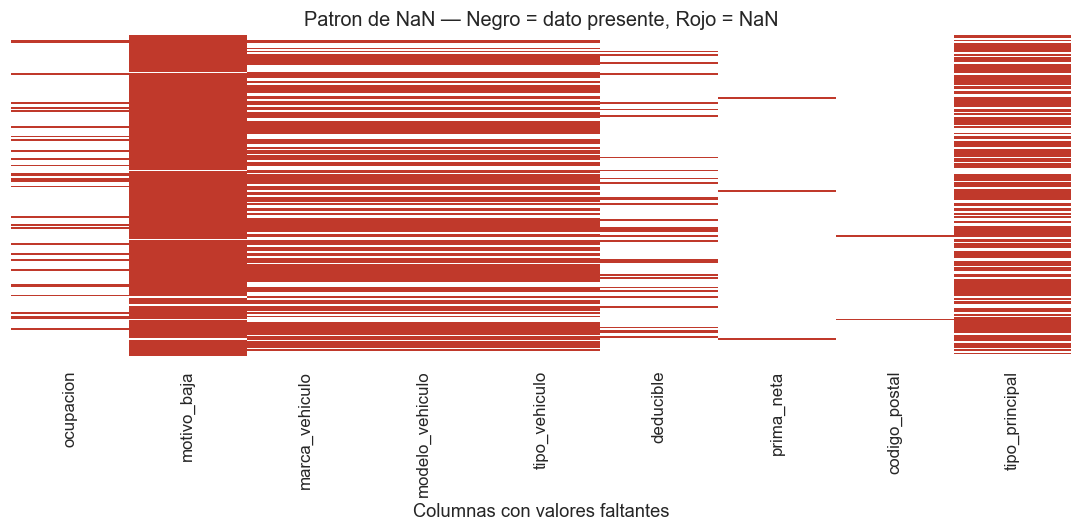

Correlacion entre columnas con NaN:
                 ocupacion  motivo_baja  marca_vehiculo  modelo_vehiculo  \
ocupacion            1.000        0.083           0.083            0.083   
motivo_baja          0.083        1.000           0.036            0.036   
marca_vehiculo       0.083        0.036           1.000            1.000   
modelo_vehiculo      0.083        0.036           1.000            1.000   
tipo_vehiculo        0.083        0.036           1.000            1.000   
deducible           -0.004       -0.065           0.313            0.313   
prima_neta          -0.054       -0.200           0.002            0.002   
codigo_postal       -0.044       -0.254          -0.034           -0.034   
tipo_principal      -0.022        0.058          -0.110           -0.110   

                 tipo_vehiculo  deducible  prima_neta  codigo_postal  \
ocupacion                0.083     -0.004      -0.054         -0.044   
motivo_baja              0.036     -0.065      -0.200      

In [3]:
# ── Visualizar patron de NaN ──────────────────────────────────────────────────
# Mapa de calor de NaN — ver si hay patrones entre columnas
cols_con_nan = [c for c in df_raw.columns if df_raw[c].isna().any()]
muestra = df_raw[cols_con_nan].sample(200, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    muestra.isna(),
    cbar=False,
    yticklabels=False,
    cmap=['white','#C0392B'],
    ax=ax
)
ax.set_title('Patron de NaN — Negro = dato presente, Rojo = NaN', fontsize=13)
ax.set_xlabel('Columnas con valores faltantes')
plt.tight_layout()
plt.show()

# Buscar si los NaN co-ocurren — si cuando falta A tambien falta B,
# probablemente son del mismo tipo o la misma fuente
print('Correlacion entre columnas con NaN:')
print(muestra.isna().corr().round(3))

---
## Bloque 2 — SimpleImputer: Imputacion Univariada

El imputer mas simple y el mas usado en produccion.
Calcula un estadistico de la columna y lo aplica a todos los NaN.

In [4]:
# ── Preparar subset numerico para imputar ────────────────────────────────────
# Trabajamos con prima_neta — tiene ~2% NaN (MCAR: error de captura)
features_num = ['prima_neta','suma_asegurada','edad','deducible']

# Solo GMM para el ejemplo (deducible tiene NaN en Vida por diseno)
df_gmm = df_raw[df_raw['ramo']=='GMM'][features_num].copy()
print(f'GMM: {df_gmm.shape}')
print('NaN:')
print(df_gmm.isna().sum())
print()

# Guardar los valores originales (los que NO son NaN) para comparar despues
prima_original = df_gmm['prima_neta'].dropna().copy()
print(f'Primas originales disponibles: {len(prima_original):,}')

GMM: (22531, 4)
NaN:
prima_neta        461
suma_asegurada      0
edad                0
deducible           0
dtype: int64

Primas originales disponibles: 22,070


In [5]:
# ── Las 4 estrategias de SimpleImputer ───────────────────────────────────────
estrategias = {
    'Media':    SimpleImputer(strategy='mean'),
    'Mediana':  SimpleImputer(strategy='median'),
    'Moda':     SimpleImputer(strategy='most_frequent'),
    'Constante':SimpleImputer(strategy='constant', fill_value=0),
}

resultados_imp = {}
for nombre, imp in estrategias.items():
    df_imp = pd.DataFrame(
        imp.fit_transform(df_gmm),
        columns=features_num
    )
    resultados_imp[nombre] = df_imp['prima_neta'].copy()
    val = imp.statistics_[features_num.index('prima_neta')]
    print(f'{nombre:<12}: imputa con ${val:,.2f}')

Media       : imputa con $26,900.09
Mediana     : imputa con $17,864.00
Moda        : imputa con $11,000.00
Constante   : imputa con $0.00


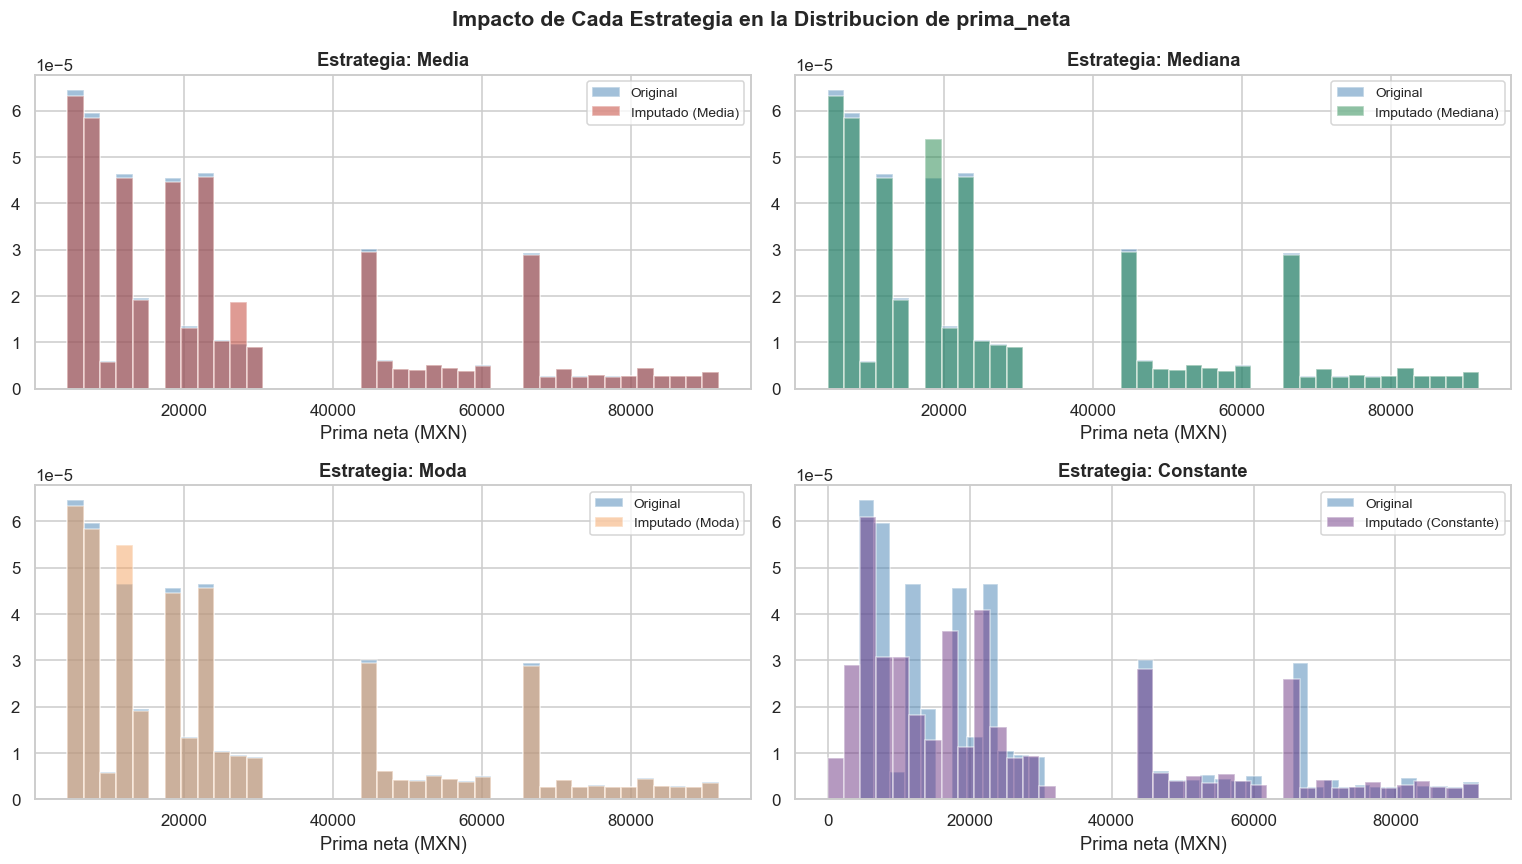

In [6]:
# ── Comparar las 4 estrategias visualmente ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colores = {'Media':'#C0392B','Mediana':'#1E8449','Moda':'#F4A261','Constante':'#6C3483'}

for ax, (nombre, serie) in zip(axes.flatten(), resultados_imp.items()):
    # Distribucion original (sin NaN)
    ax.hist(prima_original, bins=40, alpha=0.5,
            label='Original', color='steelblue', density=True)
    # Distribucion imputada
    ax.hist(serie, bins=40, alpha=0.5,
            label=f'Imputado ({nombre})', color=colores[nombre], density=True)
    ax.set_title(f'Estrategia: {nombre}', fontweight='bold')
    ax.set_xlabel('Prima neta (MXN)')
    ax.legend(fontsize=9)

fig.suptitle('Impacto de Cada Estrategia en la Distribucion de prima_neta',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# La estrategia CONSTANTE=0 es la que mas distorsiona — introduce un pico en 0
# Media y Mediana son similares aqui, pero con outliers la Mediana es mas robusta

### 📝 Ejercicio 1 — Comparar Estrategias (12 min)

**1a.** Para cada estrategia calcula: media, mediana y std de `prima_neta` despues de imputar.
Compara con los valores originales (sin NaN).

**1b.** Aplica el KS test (`stats.ks_2samp`) entre cada estrategia imputada y la distribucion original.
¿Cual tiene el p-value mas alto? (mayor p = mas similar a la original = mejor imputacion)

**1c.** ¿Que concluyes? ¿Cual estrategia recomendarias para `prima_neta` en esta cartera?

In [7]:
# Tu codigo aqui:

print(f"\nOriginal — media: ${prima_original.mean():,.2f}  "
          f"mediana: ${prima_original.median():,.2f}  "
          f"std: ${prima_original.std():,.2f}")


Original — media: $26,900.09  mediana: $17,864.00  std: $23,446.20


In [8]:
resultados = []
for nombre, imp in estrategias.items():
    df_imp = pd.DataFrame(imp.fit_transform(df_gmm), columns=features_num)
    serie  = df_imp['prima_neta']
    ks, pv = stats.ks_2samp(prima_original, serie)
    resultados.append(dict(
        estrategia=nombre,
        media=round(serie.mean(),2),
        mediana=round(serie.median(),2),
        std=round(serie.std(),2),
        ks=round(ks,4), p_value=round(pv,4),
        distorsiona='NO' if pv>0.05 else 'SI'
    ))
    print(f"{nombre:<12} media=${serie.mean():,.2f}  "
          f"mediana=${serie.median():,.2f}  "
          f"KS={ks:.4f}  p={pv:.4f}  {'OK' if pv>0.05 else 'DISTORSIONA'}")
print()
mejor = max(resultados, key=lambda x: x['p_value'])
print(f"Recomendacion: {mejor['estrategia']} "
      f"(p={mejor['p_value']:.4f} — mayor similitud con original)")
print("Para prima_neta con outliers, Mediana es la mas robusta.")

Media        media=$26,900.09  mediana=$18,128.00  KS=0.0141  p=0.0241  DISTORSIONA
Mediana      media=$26,715.21  mediana=$17,864.00  KS=0.0100  p=0.2110  OK
Moda         media=$26,574.77  mediana=$17,864.00  KS=0.0133  p=0.0374  DISTORSIONA
Constante    media=$26,349.70  mediana=$17,864.00  KS=0.0205  p=0.0002  DISTORSIONA

Recomendacion: Mediana (p=0.2110 — mayor similitud con original)
Para prima_neta con outliers, Mediana es la mas robusta.


---
## Bloque 3 — KNNImputer e IterativeImputer

Cuando el NaN es **MAR** (depende de otras variables),
los metodos univariados son insuficientes.
KNN y MICE usan el contexto de cada registro para estimar el valor faltante.

In [9]:
# ── Crear un dataset con NaN MAR para demostrar la diferencia ────────────────
# Simulamos que en polizas de mayor suma_asegurada hay mas NaN en prima_neta
# (patron MAR: el NaN depende de suma_asegurada)
np.random.seed(42)
df_demo = df_gmm.copy()

# Introducir NaN con patron MAR: mas NaN en sumas altas
prob_nan = (df_demo['suma_asegurada'] / df_demo['suma_asegurada'].max()) * 0.3
mask_nan = np.random.binomial(1, prob_nan.fillna(0)) == 1
df_demo.loc[mask_nan, 'prima_neta'] = np.nan

print(f'NaN introducidos con patron MAR: {mask_nan.sum()} ({mask_nan.mean():.1%})')
print('Verificar patron MAR:')
q33, q66 = df_demo['suma_asegurada'].quantile([0.33, 0.66])
for label, cond in [('Suma baja',df_demo['suma_asegurada']<=q33),
                    ('Suma media',(df_demo['suma_asegurada']>q33)&(df_demo['suma_asegurada']<=q66)),
                    ('Suma alta',df_demo['suma_asegurada']>q66)]:
    tasa = df_demo.loc[cond,'prima_neta'].isna().mean()
    print(f'  {label}: {tasa:.1%} NaN')
print('Si la tasa sube con la suma → es MAR')

NaN introducidos con patron MAR: 2487 (11.0%)
Verificar patron MAR:
  Suma baja: 5.2% NaN
  Suma media: 10.9% NaN
  Suma alta: 26.5% NaN
Si la tasa sube con la suma → es MAR


In [10]:
# ── KNNImputer — requiere normalizar primero ──────────────────────────────────
X_demo = df_demo[features_num].copy()

# Paso 1: normalizar (KNN es sensible a escala)
scaler = StandardScaler()
# Fit solo en filas sin NaN para no contaminar
X_sin_nan = X_demo.dropna()
scaler.fit(X_sin_nan)

# Transformar todo (con NaN — sklearn lo permite)
X_scaled = scaler.transform(X_demo)

# Paso 2: imputar en escala normalizada
imp_knn = KNNImputer(n_neighbors=5)
t0 = time.time()
X_knn = imp_knn.fit_transform(X_scaled)
t_knn = time.time()-t0

# Paso 3: regresar a escala original
X_knn_orig = scaler.inverse_transform(X_knn)
df_knn = pd.DataFrame(X_knn_orig, columns=features_num)

print(f'KNNImputer — tiempo: {t_knn:.2f}s')
print(f'NaN restantes: {df_knn.isna().sum().sum()}')

KNNImputer — tiempo: 6.55s
NaN restantes: 0


In [11]:
# ── IterativeImputer (MICE) ───────────────────────────────────────────────────
imp_mice = IterativeImputer(
    max_iter=10,
    random_state=42,
    initial_strategy='median'
)
t0 = time.time()
X_mice = imp_mice.fit_transform(X_demo)
t_mice = time.time()-t0

df_mice = pd.DataFrame(X_mice, columns=features_num)
print(f'IterativeImputer — tiempo: {t_mice:.2f}s')
print(f'NaN restantes: {df_mice.isna().sum().sum()}')
print()

# ── Comparar los tres metodos donde habia NaN artificial ─────────────────────
# IMPORTANTE: df_knn y df_mice tienen indice 0,1,2... (creados desde numpy array)
# df_demo y df_gmm tienen el indice original del parquet
# Usamos .reset_index(drop=True) para alinear todos

# Mascara booleana con indice reseteado
idx_nan = df_demo['prima_neta'].isna().reset_index(drop=True)

# Valores verdaderos (los que existian antes de poner NaN), indice reseteado
prima_verdadera = df_gmm.loc[df_demo.index, 'prima_neta'].reset_index(drop=True)

# SimpleImputer — tambien resetear indice
prima_simple = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(X_demo),
    columns=features_num
)['prima_neta']  # ya tiene indice 0,1,2...

# Ahora todos tienen el mismo indice — la comparacion funciona
print('Comparacion donde habia NaN (MAR):')
print(f'  Valor real promedio:     ${prima_verdadera[idx_nan].mean():,.2f}')
print(f'  SimpleImputer (mediana): ${prima_simple[idx_nan].mean():,.2f}')
print(f'  KNNImputer:              ${df_knn["prima_neta"][idx_nan].mean():,.2f}')
print(f'  IterativeImputer:        ${df_mice["prima_neta"][idx_nan].mean():,.2f}')
print()
print('Nota: con NaN MAR, KNN e IterativeImputer deberan acercarse mas')
print('al valor real que SimpleImputer porque usan el contexto de cada fila.')


IterativeImputer — tiempo: 0.07s
NaN restantes: 0

Comparacion donde habia NaN (MAR):
  Valor real promedio:     $46,573.24
  SimpleImputer (mediana): $17,600.00
  KNNImputer:              $43,559.83
  IterativeImputer:        $43,493.87

Nota: con NaN MAR, KNN e IterativeImputer deberan acercarse mas
al valor real que SimpleImputer porque usan el contexto de cada fila.


---
## Bloque 3 — KNNImputer e IterativeImputer

### Por qué SimpleImputer falla cuando el NaN es MAR

Imagina estas 5 pólizas de GMM donde falta la prima de la última:

| edad | suma_asegurada | prima_neta |
|------|---------------|------------|
| 28   | 200,000       | 2,100      |
| 32   | 250,000       | 2,400      |
| 45   | 800,000       | 9,200      |
| 55   | 1,000,000     | 12,500     |
| 48   | 900,000       | **NaN**    |

**SimpleImputer** calcula la mediana de toda la columna → $2,400.
Imputa $2,400 para una póliza de suma asegurada de $900,000. Eso está muy mal.

El NaN no es aleatorio — falta sistemáticamente en pólizas de suma alta.
Eso es **MAR**: el faltante depende de otra variable.

---

### Como funciona KNNImputer

**La pregunta que se hace:** ¿cuáles son las pólizas más parecidas a esta?

Para la póliza con NaN (edad=48, suma=900,000):

1. Calcula la distancia a todas las demás pólizas usando las columnas sin NaN
2. Encuentra las k más cercanas — las más similares en edad y suma asegurada
3. Promedia sus primas y usa ese promedio como valor imputado

Con k=2 vecinos más cercanos (sumas de 800k y 1M):
prima imputada = (9,200 + 12,500) / 2 = 10,850


Mucho más realista que la mediana global de $2,400.

**Por qué hay que normalizar antes de usar KNN:**
Si suma_asegurada va de 0 a 1,000,000 y edad va de 18 a 70,
sin normalizar la distancia queda dominada completamente por la suma.
La póliza "más cercana" siempre sería la de suma más parecida, ignorando la edad.
Al normalizar con `StandardScaler`, ambas variables pesan por igual en la distancia.

**El parámetro k:**
- k pequeño (k=3): más sensible al contexto local, más preciso si los vecinos son buenos
- k grande (k=20): más suave, más parecido a la media — pierde la ventaja del método
- No hay un k universal — se elige evaluando el MAE en datos conocidos

---

### Como funciona IterativeImputer (MICE)

**La pregunta que se hace:** ¿puedo modelar `prima_neta` como función de las demás variables?

**Iteración 1:**
1. Rellena todos los NaN con la mediana — es el punto de partida
2. Ajusta una regresión: `prima_neta ~ edad + suma_asegurada + deducible`
3. Predice `prima_neta` donde faltaba — ya mucho mejor que la mediana

**Iteración 2:**
4. Usa los valores predichos como si fueran reales
5. Vuelve a ajustar la misma regresión con esos valores actualizados
6. Predice de nuevo — el resultado cambia ligeramente

**Iteraciones 3 al 10:**
Repite hasta que los valores predichos casi no cambian entre una iteración
y la siguiente. En ese momento se dice que **convergió**.

El resultado es una prima imputada que respeta la relación real entre las variables.
Es el método más preciso pero también el más lento.

**Cuándo elegir MICE sobre KNN:**
- Tienes varias columnas con NaN al mismo tiempo y están correlacionadas entre sí
- El dataset tiene muchas variables y la relación entre ellas es lineal
- La precisión importa más que la velocidad

---

### El código de simulación MAR — qué hace cada línea

El parquet ya está limpio, así que construimos NaN artificiales con un patrón MAR
para poder demostrar la diferencia entre métodos.

```python
prob_nan = (df_demo['suma_asegurada'] / df_demo['suma_asegurada'].max()) * 0.3
```
Crea una probabilidad de NaN proporcional a la suma asegurada:
- Suma = 0 → 0% de probabilidad de NaN
- Suma = 500,000 (mitad del máximo) → 15% de probabilidad
- Suma = 1,000,000 (el máximo) → 30% de probabilidad

```python
mask_nan = np.random.binomial(1, prob_nan.fillna(0)) == 1
```
`np.random.binomial(1, p)` es un lanzamiento de moneda con probabilidad `p`.
Para cada fila lanza su moneda. Si sale 1 → NaN. Si sale 0 → conserva el valor.
Las pólizas de suma alta tienen más probabilidad de quedarse sin prima. Eso es MAR.

```python
for label, cond in [('Suma baja', ...), ('Suma media', ...), ('Suma alta', ...)]:
    tasa = df_demo.loc[cond, 'prima_neta'].isna().mean()
```
Verifica que el patrón quedó bien. Deberías ver algo como:

Suma baja:   ~3% NaN
Suma media:  ~13% NaN
Suma alta:   ~24% NaN

Si las tasas suben con la suma, el patrón MAR está bien simulado.
Con SimpleImputer estás imputando la misma mediana global para sumas de 100,000
y para sumas de 900,000 — que claramente no deberían tener la misma prima.


### 📝 Ejercicio 2 — KNN vs MICE (15 min)

**2a.** Para los registros donde introdujimos NaN artificialmente (variable `idx_nan`),
calcula el **Error Absoluto Medio (MAE)** entre el valor real y el valor imputado
por cada metodo: SimpleImputer, KNNImputer e IterativeImputer.

**2b.** Visualiza los tres metodos en un scatter:
eje X = valor real, eje Y = valor imputado.
El metodo perfecto tendria todos los puntos en la diagonal y=x.

**2c.** Prueba KNNImputer con k=3, k=5, k=10 y k=20.
¿Cual k da el menor MAE para este dataset?

**2d.** ¿En que situaciones de la cartera real usarias MICE en lugar de SimpleImputer?

### 📝 Ejercicio 2 — Comparar KNN vs MICE (15 min)

En la celda anterior introdujimos NaN artificiales con patrón MAR en `prima_neta`.
Como nosotros los pusimos, sabemos cuál era el valor real antes de borrarlos.
Eso nos permite medir qué tan bien imputa cada método.

**Variable clave:** `idx_nan` es una máscara booleana con `True` en las filas
donde pusimos NaN. `prima_verdadera[idx_nan]` son los valores que "ocultamos".

---

**2a. Calcular el error de cada método**

Para cada uno de los tres métodos ya imputados (SimpleImputer, KNNImputer, IterativeImputer),
filtra solo las filas donde había NaN con `idx_nan` y calcula:

```python
mae = mean_absolute_error(prima_verdadera[idx_nan], valores_imputados[idx_nan])
```

El MAE te dice en promedio cuántos pesos se equivocó cada método.
Si el valor real era $10,000 y imputó $8,500 → error = $1,500.

¿Cuál método se equivoca menos?

---

**2b. Visualizar real vs imputado**

Construye un scatter para cada método donde:
- Eje X = valor real de prima_neta (el que ocultamos)
- Eje Y = valor imputado por el método

Si el método fuera perfecto, todos los puntos caerían exactamente sobre
la línea diagonal y = x (agrega esa línea en rojo).

Cuanto más dispersos estén los puntos respecto a esa diagonal,
peor es el método. Espera ver que SimpleImputer tiene puntos agrupados
en una línea horizontal (siempre imputa lo mismo) mientras KNN y MICE
tienen puntos más cerca de la diagonal.

---

**2c. ¿Cuál k es el mejor para KNN?**

El parámetro k no tiene un valor universal — depende de los datos.
Entrena KNNImputer con k = 3, 5, 10 y 20. Para cada uno calcula el MAE.

```python
for k in [3, 5, 10, 20]:
    imp = KNNImputer(n_neighbors=k)
    # ... imputar y calcular MAE
    print(f'k={k}: MAE=${mae:,.0f}')
```

¿Hay un k donde el MAE toca un mínimo? ¿O sigue bajando conforme k aumenta?

---

**2d. Reflexión**

Responde en una celda de texto:
¿En qué columnas de la cartera real usarías MICE en lugar de SimpleImputer?
Piensa en qué variables tienen NaN que podrían depender de otras variables
(edad, suma asegurada, ramo, zona).

In [12]:
print("="*60)
print("  SOLUCION E2 — KNN vs MICE — MAE Comparativo")
print("="*60)
# ── Preparar datos con patron MAR ────────────────────────────────────────────
# IMPORTANTE: empezar con filas COMPLETAS (sin NaN previos del setup)
# df_gmm puede tener NaN del 2% introducido en la celda de setup
# Si no limpiamos, prima_verdadera_arr contiene NaN y MAE explota
np.random.seed(42)
df_demo = df_gmm.dropna().copy().reset_index(drop=True)  # solo filas completas
prob_nan = (df_demo['suma_asegurada'] / df_demo['suma_asegurada'].max()) * 0.3
mask_nan_bool = (np.random.binomial(1, prob_nan.fillna(0)) == 1)
# Guardar los valores reales ANTES de poner NaN — ahora sin NaN garantizado
prima_verdadera_arr = df_demo['prima_neta'].values.copy()
df_demo.loc[mask_nan_bool, 'prima_neta'] = np.nan
print(f"Filas de trabajo: {len(df_demo):,}  |  NaN introducidos: {mask_nan_bool.sum()}")
# Normalizar para KNN y MICE — fit solo en filas completas
scaler = StandardScaler()
scaler.fit(df_demo.dropna())  # fit solo en filas completas
X_sc = scaler.transform(df_demo)  # transform tolera NaN — los imputers los llenan  # contiene NaN donde df_demo tiene NaN — OK para imputers
# ── 2a: MAE por metodo ────────────────────────────────────────────────────────
print(f"\n2a. MAE en los {mask_nan_bool.sum()} registros con NaN artificial (MAR):")
pred_guardadas = {}  # guardar para 2b
for nombre, imp in [
    ('SimpleImputer', SimpleImputer(strategy='median')),
    ('KNNImputer k=5', KNNImputer(n_neighbors=5)),
    ('MICE',          IterativeImputer(max_iter=10, random_state=42)),
]:
    if 'Simple' in nombre:
        # SimpleImputer trabaja directo sobre el DataFrame
        X_imp = imp.fit_transform(df_demo)
    else:
        # KNN y MICE trabajan sobre los datos normalizados
        X_imp_sc = imp.fit_transform(X_sc)
        X_imp = scaler.inverse_transform(X_imp_sc)
    # Extraer prima_neta imputada como array numpy
    idx_prima = features_num.index('prima_neta')
    pred_arr  = X_imp[:, idx_prima]
    # Calcular MAE solo donde habia NaN — usando mascara booleana numpy
    mae = mean_absolute_error(
        prima_verdadera_arr[mask_nan_bool],
        pred_arr[mask_nan_bool]
    )
    print(f"  {nombre:<20}: MAE=${mae:,.2f}")
    pred_guardadas[nombre] = pred_arr


  SOLUCION E2 — KNN vs MICE — MAE Comparativo
Filas de trabajo: 22,070  |  NaN introducidos: 2489

2a. MAE en los 2489 registros con NaN artificial (MAR):
  SimpleImputer       : MAE=$31,327.90
  KNNImputer k=5      : MAE=$1,228.73
  MICE                : MAE=$3,640.85



2b. Generando scatter real vs imputado...


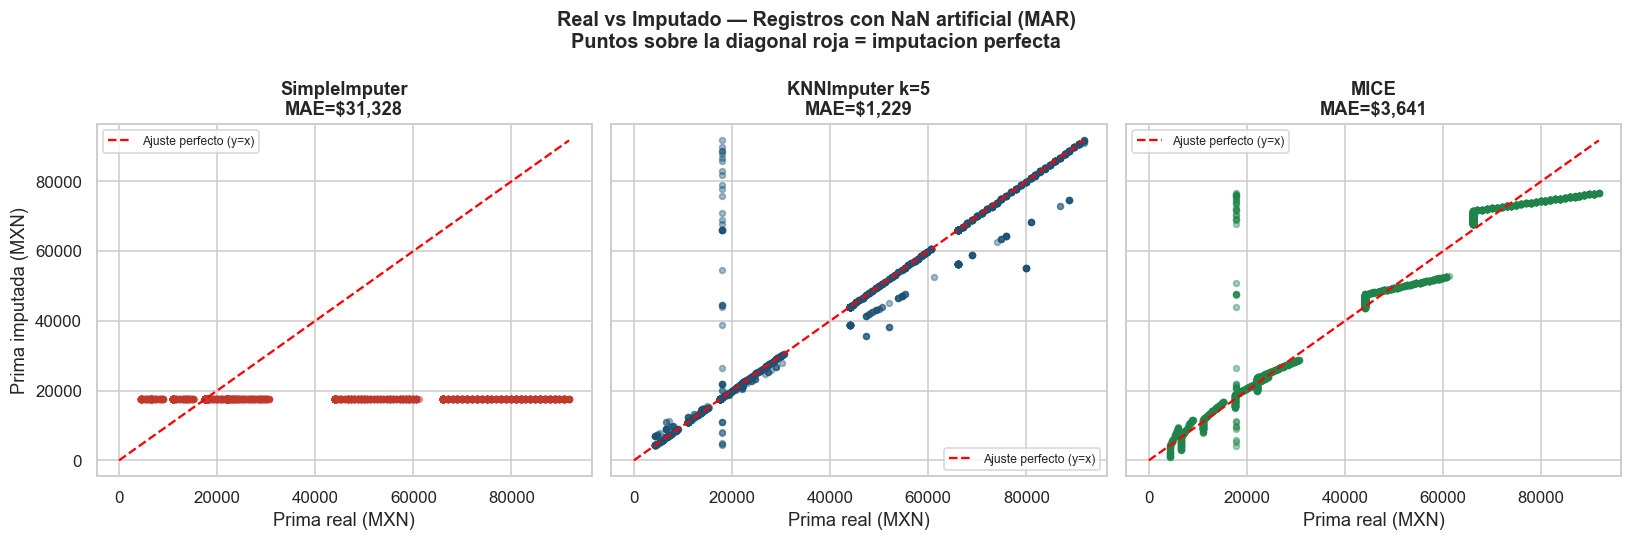

  SimpleImputer: puntos agrupados en linea horizontal (siempre el mismo valor)
  KNN y MICE:    puntos mas cerca de la diagonal (respetan la variacion real)

2c. KNNImputer con distintos k:
  k= 3: MAE=$1,467.36
  k= 5: MAE=$1,228.73
  k=10: MAE=$1,360.15
  k=20: MAE=$1,370.28

2d. Usar MICE cuando hay varias columnas con NaN correlacionadas entre si.
    En la cartera: prima_neta y deducible tienen correlacion — MICE es mejor.


In [13]:
# ── 2b: Scatter real vs imputado ──────────────────────────────────────────────
print("\n2b. Generando scatter real vs imputado...")
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
colores = {'SimpleImputer':'#C0392B', 'KNNImputer k=5':'#1A5276', 'MICE':'#1E8449'}
for ax, (nombre, pred_arr) in zip(axes, pred_guardadas.items()):
    real_f = prima_verdadera_arr[mask_nan_bool]
    pred_f = pred_arr[mask_nan_bool]
    mae_v  = mean_absolute_error(real_f, pred_f)
    ax.scatter(real_f, pred_f, alpha=0.4, s=15, color=colores[nombre])
    lim = max(real_f.max(), pred_f.max())
    ax.plot([0, lim], [0, lim], color='red', linestyle='--',
            linewidth=1.5, label='Ajuste perfecto (y=x)')
    ax.set_title(f'{nombre}\nMAE=${mae_v:,.0f}', fontweight='bold')
    ax.set_xlabel('Prima real (MXN)')
    if ax == axes[0]:
        ax.set_ylabel('Prima imputada (MXN)')
    ax.legend(fontsize=8)
fig.suptitle(
    'Real vs Imputado — Registros con NaN artificial (MAR)\n'
    'Puntos sobre la diagonal roja = imputacion perfecta',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()
print("  SimpleImputer: puntos agrupados en linea horizontal (siempre el mismo valor)")
print("  KNN y MICE:    puntos mas cerca de la diagonal (respetan la variacion real)")
# ── 2c: Comparar distintos k ──────────────────────────────────────────────────
print("\n2c. KNNImputer con distintos k:")
for k in [3, 5, 10, 20]:
    X_knn    = KNNImputer(n_neighbors=k).fit_transform(X_sc)
    pred_arr = scaler.inverse_transform(X_knn)[:, features_num.index('prima_neta')]
    mae      = mean_absolute_error(
        prima_verdadera_arr[mask_nan_bool],
        pred_arr[mask_nan_bool]
    )
    print(f"  k={k:>2}: MAE=${mae:,.2f}")
print()
print("2d. Usar MICE cuando hay varias columnas con NaN correlacionadas entre si.")
print("    En la cartera: prima_neta y deducible tienen correlacion — MICE es mejor.")


---
## Bloque 4 — Evaluar el Impacto


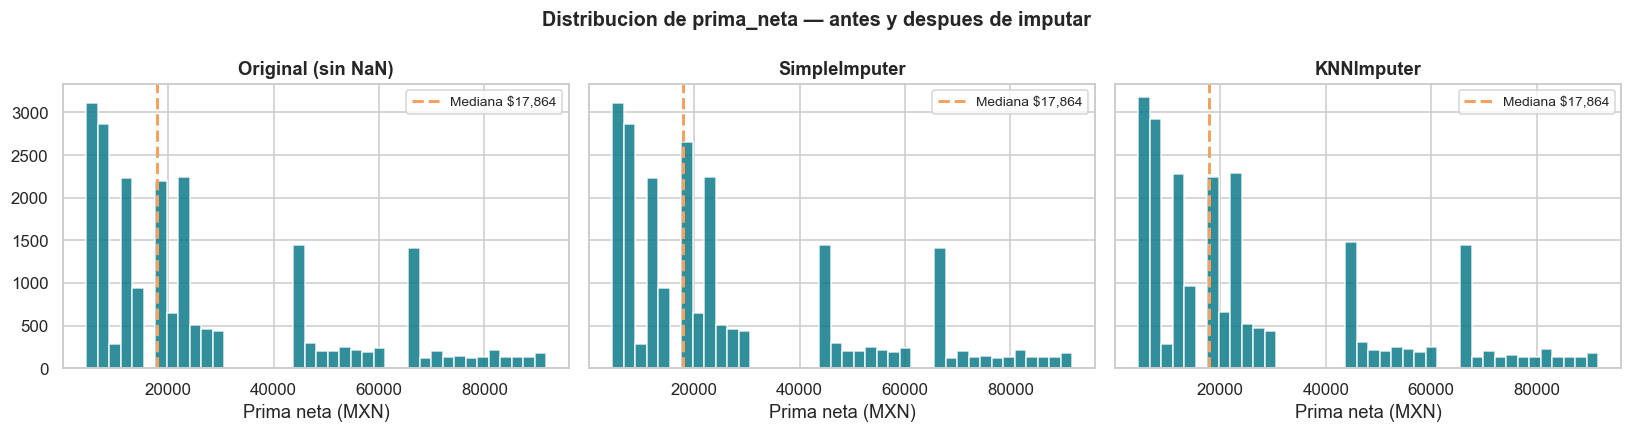

In [14]:
# ── Comparar distribuciones antes y despues ──────────────────────────────────
# Dataset completo — comparar SimpleImputer vs KNNImputer

df_trabajo = df_raw[df_raw['ramo']=='GMM'][features_num].copy()
prima_original_full = df_trabajo['prima_neta'].dropna()

# SimpleImputer con mediana
df_simple = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(df_trabajo),
    columns=features_num
)

# KNNImputer
scaler2 = StandardScaler()
X_sc2 = scaler2.fit_transform(df_trabajo)
X_knn2 = KNNImputer(n_neighbors=5).fit_transform(X_sc2)
df_knn2 = pd.DataFrame(scaler2.inverse_transform(X_knn2), columns=features_num)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (nombre, serie) in zip(axes, [
    ('Original (sin NaN)', prima_original_full),
    ('SimpleImputer',      df_simple['prima_neta']),
    ('KNNImputer',         df_knn2['prima_neta']),
]):
    ax.hist(serie, bins=40, color='#0D7A8A', edgecolor='white', alpha=0.85)
    ax.axvline(serie.median(), color='#F4A261', linewidth=2,
               linestyle='--', label=f'Mediana ${serie.median():,.0f}')
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Prima neta (MXN)')
    ax.legend(fontsize=9)

fig.suptitle('Distribucion de prima_neta — antes y despues de imputar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ── KS Test formal ───────────────────────────────────────────────────────────
for nombre, serie in [('SimpleImputer', df_simple['prima_neta']),
                      ('KNNImputer',    df_knn2['prima_neta'])]:
    ks, pv = stats.ks_2samp(prima_original_full, serie)
    print(f'{nombre:<18}: KS={ks:.4f}  p={pv:.4f}  '","
          f"{'OK - no distorsiona' if pv>0.05 else 'DISTORSIONA la distribucion'}")
print()
print('p > 0.05 significa que la imputacion no distorsiona significativamente')

SimpleImputer     : KS=0.0100  p=0.2110  ,OK - no distorsiona
KNNImputer        : KS=0.0036  p=0.9987  ,OK - no distorsiona

p > 0.05 significa que la imputacion no distorsiona significativamente


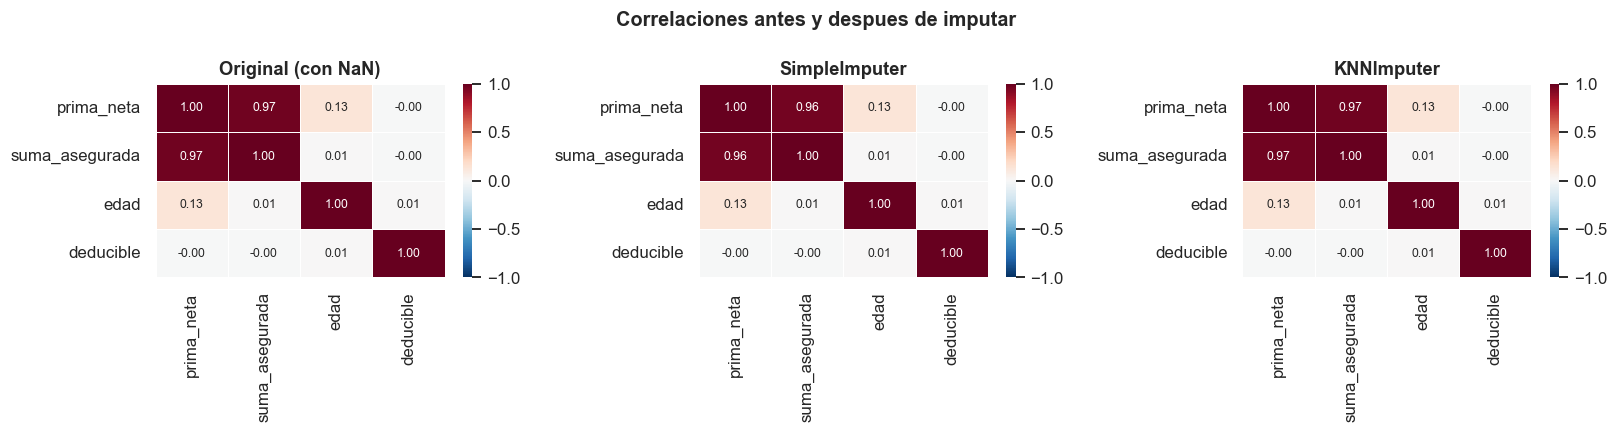

Diferencia maxima en correlaciones: 0.0111


In [16]:
# ── Comparar correlaciones antes y despues ───────────────────────────────────
corr_original = df_trabajo.corr(numeric_only=True)
corr_simple   = df_simple.corr(numeric_only=True)
corr_knn      = df_knn2.corr(numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kws = dict(annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
           linewidths=0.5, annot_kws={'size':8})

sns.heatmap(corr_original, ax=axes[0], **kws)
axes[0].set_title('Original (con NaN)', fontweight='bold')
sns.heatmap(corr_simple, ax=axes[1], **kws)
axes[1].set_title('SimpleImputer', fontweight='bold')
sns.heatmap(corr_knn, ax=axes[2], **kws)
axes[2].set_title('KNNImputer', fontweight='bold')

fig.suptitle('Correlaciones antes y despues de imputar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

diff = (corr_simple - corr_knn).abs()
print(f'Diferencia maxima en correlaciones: {diff.max().max():.4f}')

### Solucion Ejercicio 1

In [17]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import time, sys, warnings
warnings.filterwarnings('ignore')

import os
rutas = [
    'C:/Users/HP/diplomado-ml-seguros/Modulo_1/sesion_10/datos/cartera_q1_2026_final.parquet',
    'datos/tabla_maestra_s9.parquet',
    '../sesion_10/datos/cartera_q1_2026_final.parquet',
    'datos/cartera_q1_2026_final.parquet',
]
ruta = next((r for r in rutas if os.path.exists(r)), None)
if ruta is None:
    raise FileNotFoundError('No se encontro el parquet.')
df_raw = pd.read_parquet(ruta)
np.random.seed(2026)
N = len(df_raw)
idx_prima = np.random.choice(N, int(N*0.02), replace=False)
df_raw.loc[df_raw.index[idx_prima], 'prima_neta'] = np.nan
df_raw.loc[df_raw['ramo']=='Vida', 'deducible'] = np.nan
if 'ocupacion' in df_raw.columns:
    prob = ((df_raw['edad']-18)/(70-18))*0.20
    df_raw.loc[np.random.binomial(1,prob)==1, 'ocupacion'] = np.nan

features_num = ['prima_neta','suma_asegurada','edad','deducible']
df_gmm = df_raw[df_raw['ramo']=='GMM'][features_num].copy()
prima_original = df_gmm['prima_neta'].dropna()


def solucion_e1():
    print("="*60)
    print("  SOLUCION E1 — Comparar Estrategias de Imputacion")
    print("="*60)
    estrategias = {
        'Media':    SimpleImputer(strategy='mean'),
        'Mediana':  SimpleImputer(strategy='median'),
        'Moda':     SimpleImputer(strategy='most_frequent'),
        'Constante':SimpleImputer(strategy='constant', fill_value=0),
    }
    print(f"\nOriginal — media: ${prima_original.mean():,.2f}  "
          f"mediana: ${prima_original.median():,.2f}  "
          f"std: ${prima_original.std():,.2f}")
    print()
    resultados = []
    for nombre, imp in estrategias.items():
        df_imp = pd.DataFrame(imp.fit_transform(df_gmm), columns=features_num)
        serie  = df_imp['prima_neta']
        ks, pv = stats.ks_2samp(prima_original, serie)
        resultados.append(dict(
            estrategia=nombre,
            media=round(serie.mean(),2),
            mediana=round(serie.median(),2),
            std=round(serie.std(),2),
            ks=round(ks,4), p_value=round(pv,4),
            distorsiona='NO' if pv>0.05 else 'SI'
        ))
        print(f"{nombre:<12} media=${serie.mean():,.2f}  "
              f"mediana=${serie.median():,.2f}  "
              f"KS={ks:.4f}  p={pv:.4f}  {'OK' if pv>0.05 else 'DISTORSIONA'}")
    print()
    mejor = max(resultados, key=lambda x: x['p_value'])
    print(f"Recomendacion: {mejor['estrategia']} "
          f"(p={mejor['p_value']:.4f} — mayor similitud con original)")
    print("Para prima_neta con outliers, Mediana es la mas robusta.")

solucion_e1()

  SOLUCION E1 — Comparar Estrategias de Imputacion

Original — media: $26,900.09  mediana: $17,864.00  std: $23,446.20

Media        media=$26,900.09  mediana=$18,128.00  KS=0.0141  p=0.0241  DISTORSIONA
Mediana      media=$26,715.21  mediana=$17,864.00  KS=0.0100  p=0.2110  OK
Moda         media=$26,574.77  mediana=$17,864.00  KS=0.0133  p=0.0374  DISTORSIONA
Constante    media=$26,349.70  mediana=$17,864.00  KS=0.0205  p=0.0002  DISTORSIONA

Recomendacion: Mediana (p=0.2110 — mayor similitud con original)
Para prima_neta con outliers, Mediana es la mas robusta.


### Solucion Ejercicio 2

  SOLUCION E2 — KNN vs MICE — MAE Comparativo
Filas de trabajo: 22,070  |  NaN introducidos: 2489

2a. MAE en los 2489 registros con NaN artificial (MAR):
  SimpleImputer       : MAE=$31,327.90
  KNNImputer k=5      : MAE=$1,228.73
  MICE                : MAE=$3,640.85

2b. Generando scatter real vs imputado...


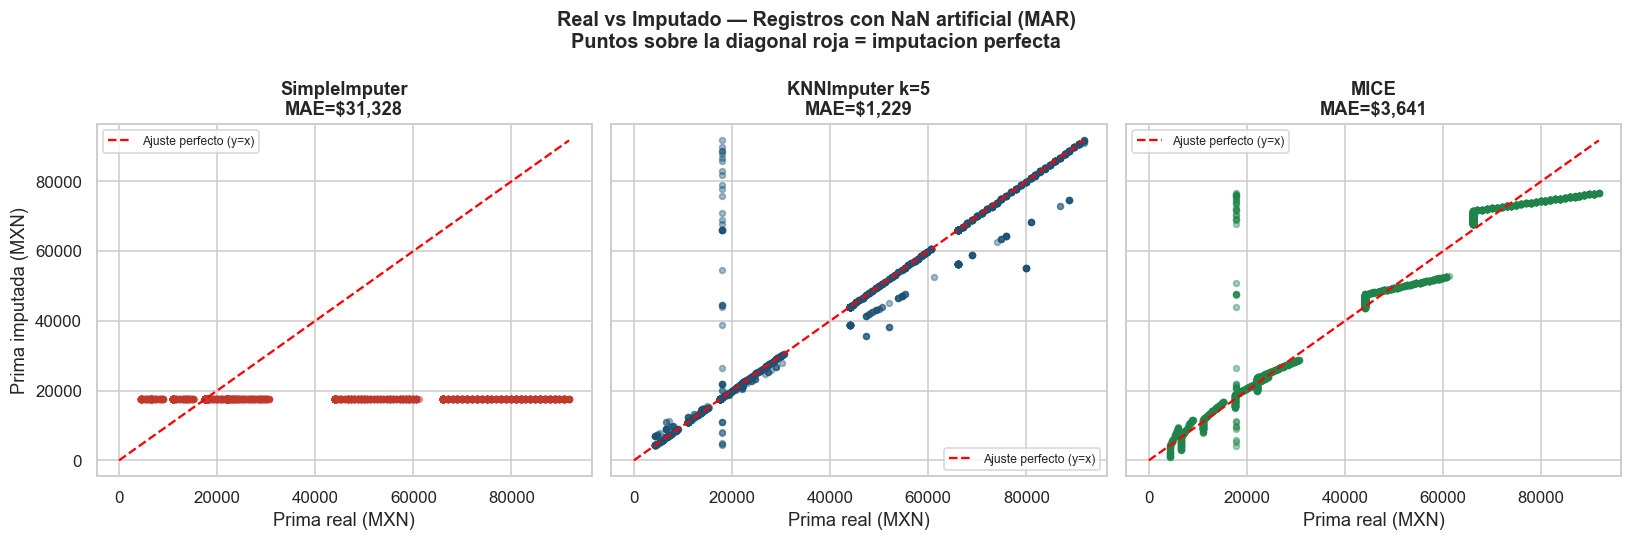

  SimpleImputer: puntos agrupados en linea horizontal (siempre el mismo valor)
  KNN y MICE:    puntos mas cerca de la diagonal (respetan la variacion real)

2c. KNNImputer con distintos k:
  k= 3: MAE=$1,467.36
  k= 5: MAE=$1,228.73
  k=10: MAE=$1,360.15
  k=20: MAE=$1,370.28

2d. Usar MICE cuando hay varias columnas con NaN correlacionadas entre si.
    En la cartera: prima_neta y deducible tienen correlacion — MICE es mejor.


In [18]:
def solucion_e2():
    print("="*60)
    print("  SOLUCION E2 — KNN vs MICE — MAE Comparativo")
    print("="*60)

    # ── Preparar datos con patron MAR ────────────────────────────────────────────
    # IMPORTANTE: empezar con filas COMPLETAS (sin NaN previos del setup)
    # df_gmm puede tener NaN del 2% introducido en la celda de setup
    # Si no limpiamos, prima_verdadera_arr contiene NaN y MAE explota
    np.random.seed(42)
    df_demo = df_gmm.dropna().copy().reset_index(drop=True)  # solo filas completas

    prob_nan = (df_demo['suma_asegurada'] / df_demo['suma_asegurada'].max()) * 0.3
    mask_nan_bool = (np.random.binomial(1, prob_nan.fillna(0)) == 1)

    # Guardar los valores reales ANTES de poner NaN — ahora sin NaN garantizado
    prima_verdadera_arr = df_demo['prima_neta'].values.copy()

    df_demo.loc[mask_nan_bool, 'prima_neta'] = np.nan
    print(f"Filas de trabajo: {len(df_demo):,}  |  NaN introducidos: {mask_nan_bool.sum()}")

    # Normalizar para KNN y MICE — fit solo en filas completas
    scaler = StandardScaler()
    scaler.fit(df_demo.dropna())  # fit solo en filas completas
    X_sc = scaler.transform(df_demo)  # transform tolera NaN — los imputers los llenan  # contiene NaN donde df_demo tiene NaN — OK para imputers

    # ── 2a: MAE por metodo ────────────────────────────────────────────────────────
    print(f"\n2a. MAE en los {mask_nan_bool.sum()} registros con NaN artificial (MAR):")
    pred_guardadas = {}  # guardar para 2b

    for nombre, imp in [
        ('SimpleImputer', SimpleImputer(strategy='median')),
        ('KNNImputer k=5', KNNImputer(n_neighbors=5)),
        ('MICE',          IterativeImputer(max_iter=10, random_state=42)),
    ]:
        if 'Simple' in nombre:
            # SimpleImputer trabaja directo sobre el DataFrame
            X_imp = imp.fit_transform(df_demo)
        else:
            # KNN y MICE trabajan sobre los datos normalizados
            X_imp_sc = imp.fit_transform(X_sc)
            X_imp = scaler.inverse_transform(X_imp_sc)

        # Extraer prima_neta imputada como array numpy
        idx_prima = features_num.index('prima_neta')
        pred_arr  = X_imp[:, idx_prima]

        # Calcular MAE solo donde habia NaN — usando mascara booleana numpy
        mae = mean_absolute_error(
            prima_verdadera_arr[mask_nan_bool],
            pred_arr[mask_nan_bool]
        )
        print(f"  {nombre:<20}: MAE=${mae:,.2f}")
        pred_guardadas[nombre] = pred_arr

    # ── 2b: Scatter real vs imputado ──────────────────────────────────────────────
    print("\n2b. Generando scatter real vs imputado...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
    colores = {'SimpleImputer':'#C0392B', 'KNNImputer k=5':'#1A5276', 'MICE':'#1E8449'}

    for ax, (nombre, pred_arr) in zip(axes, pred_guardadas.items()):
        real_f = prima_verdadera_arr[mask_nan_bool]
        pred_f = pred_arr[mask_nan_bool]
        mae_v  = mean_absolute_error(real_f, pred_f)

        ax.scatter(real_f, pred_f, alpha=0.4, s=15, color=colores[nombre])

        lim = max(real_f.max(), pred_f.max())
        ax.plot([0, lim], [0, lim], color='red', linestyle='--',
                linewidth=1.5, label='Ajuste perfecto (y=x)')

        ax.set_title(f'{nombre}\nMAE=${mae_v:,.0f}', fontweight='bold')
        ax.set_xlabel('Prima real (MXN)')
        if ax == axes[0]:
            ax.set_ylabel('Prima imputada (MXN)')
        ax.legend(fontsize=8)

    fig.suptitle(
        'Real vs Imputado — Registros con NaN artificial (MAR)\n'
        'Puntos sobre la diagonal roja = imputacion perfecta',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    print("  SimpleImputer: puntos agrupados en linea horizontal (siempre el mismo valor)")
    print("  KNN y MICE:    puntos mas cerca de la diagonal (respetan la variacion real)")

    # ── 2c: Comparar distintos k ──────────────────────────────────────────────────
    print("\n2c. KNNImputer con distintos k:")
    for k in [3, 5, 10, 20]:
        X_knn    = KNNImputer(n_neighbors=k).fit_transform(X_sc)
        pred_arr = scaler.inverse_transform(X_knn)[:, features_num.index('prima_neta')]
        mae      = mean_absolute_error(
            prima_verdadera_arr[mask_nan_bool],
            pred_arr[mask_nan_bool]
        )
        print(f"  k={k:>2}: MAE=${mae:,.2f}")

    print()
    print("2d. Usar MICE cuando hay varias columnas con NaN correlacionadas entre si.")
    print("    En la cartera: prima_neta y deducible tienen correlacion — MICE es mejor.")

solucion_e2()

---
## Ejercicio Integrador — Pipeline Completo de Imputacion

Construye el pipeline de imputacion completo para preparar la cartera
para un modelo predictivo. Cada decision debe estar justificada.

### Las 4 Fases

**Fase 1 — Diagnostico**
Para cada columna con NaN, determina si es MCAR, MAR o MNAR.
Justifica con datos — no intuicion.

**Fase 2 — Estrategia por columna**
Diseña la estrategia de imputacion para cada columna.
No todas las columnas necesitan el mismo metodo.

**Fase 3 — Implementar y evaluar**
Aplica las estrategias. Para las columnas numericas clave,
verifica con KS test que la distribucion no se distorsiona.

**Fase 4 — Impacto en el modelo**
Entrena tres Pipelines sklearn (SimpleImputer, KNNImputer, IterativeImputer)
con LinearRegression para predecir `prima_total`.
Compara R2 y MAE. ¿Que metodo de imputacion da el mejor modelo?

In [19]:
def solucion_final():
    print("="*60)
    print("  SOLUCION INTEGRADOR — Pipeline Completo")
    print("="*60)
    features_modelo = ['edad','suma_asegurada','deducible','n_siniestros']
    df_modelo = df_raw[features_modelo+['prima_total']].dropna(subset=['prima_total'])
    X = df_modelo[features_modelo]
    y = df_modelo['prima_total']
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

    print("\nFase 4 — Impacto en el modelo (LinearRegression):")
    for nombre, imp in [
        ('SimpleImputer (median)', SimpleImputer(strategy='median')),
        ('KNNImputer (k=5)',       KNNImputer(n_neighbors=5)),
        ('IterativeImputer',       IterativeImputer(max_iter=10, random_state=42)),
    ]:
        pipe = Pipeline([('imp', imp), ('sc', StandardScaler()), ('mod', LinearRegression())])
        pipe.fit(X_tr, y_tr)
        yp   = pipe.predict(X_te)
        print(f"  {nombre:<28}: R2={r2_score(y_te,yp):.4f}  MAE=${mean_absolute_error(y_te,yp):,.0f}")
    print()
    print("Conclusion: en este caso la diferencia entre metodos es pequena.")
    print("La imputacion importa mas cuando el % de NaN es alto (>10%).")
    print("Para prima_neta (~2% NaN) cualquier metodo razonable funciona bien.")

solucion_final()

  SOLUCION INTEGRADOR — Pipeline Completo

Fase 4 — Impacto en el modelo (LinearRegression):
  SimpleImputer (median)      : R2=0.9519  MAE=$4,725
  KNNImputer (k=5)            : R2=0.9518  MAE=$4,702
  IterativeImputer            : R2=0.9518  MAE=$4,691

Conclusion: en este caso la diferencia entre metodos es pequena.
La imputacion importa mas cuando el % de NaN es alto (>10%).
Para prima_neta (~2% NaN) cualquier metodo razonable funciona bien.


---
## Resumen

| Metodo | Cuando usarlo | Ventaja | Limitacion |
|--------|--------------|---------|------------|
| **SimpleImputer** | MCAR, pocas filas afectadas | Rapido, reproducible | Ignora relaciones entre variables |
| **KNNImputer** | MAR, variables correlacionadas | Usa contexto local | Lento, sensible a escala |
| **IterativeImputer** | MAR, muchas variables correlacionadas | Gold standard estadistico | Mas lento, requiere ajuste |

**Regla de oro:** fit() solo en datos de entrenamiento. Nunca en test.